In [1]:
# import pickle

# pose = True
# with open("data.pkl", "wb") as f:
#     pickle.dump(pose, f)

# with open("data.pkl", "rb") as f:
#     pose = pickle.load(f)
# pose

In [6]:
import mediapipe as mp
import cv2
import numpy as np

In [7]:
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

In [ ]:
import mediapipe as mp
import cv2
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from collections import deque

def calculate_loss(predicted, actual):
    mae_loss = nn.MSELoss()
    loss = mae_loss(torch.tensor(predicted),torch.tensor(actual))
    return loss.item()

def calculate_angle(a, b, c):
    a = np.array(a)  # First
    b = np.array(b)  # Mid
    c = np.array(c)  # End
    
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    
    if angle > 180.0:
        angle = 360 - angle
        
    return angle

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
# Load the LSTM model

lstm_model = torch.jit.load(r'model_path/model_pushup_scripted.pt')#for linux relative path
lstm_model.to(device) 
lstm_model.eval()
# Initialize MediaPipe pose
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

# Video Capture
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

# Variables for counting and tracking
stage = ""
counter = 0

# Scaling angles
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(np.array([[0] * 7, [180] * 7]))


input_window= 20
output_window = 5
pred_freq = 5

# Store pose sequences
pose_sequences = deque(maxlen=input_window )
real_time_storage = []
frame_count = 0
collecting_real_time = False #this is a flag.false-during prediction, true-calculating real time values. 
predicted_vs_real_storage = [] 
focus_angles=[]
realtime_loss = []
run_buffer=[]
loss_buffer=[]
threshold=300
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert frame to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False
        
        # Detect pose
        results = pose.process(image)
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark

            # Draw pose landmarks
            mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                      mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=2),
                                      mp_drawing.DrawingSpec(color=(0,0,255), thickness=2, circle_radius=2))

            # Define angles to calculate
            angles_to_calculate = {
                "right_elbow_right_shoulder_right_hip": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                ],
                "left_elbow_left_shoulder_left_hip": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                ],
                "right_knee_mid_hip_left_knee": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x) / 2,
                     (landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y) / 2],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                ],
                "right_hip_right_knee_right_ankle": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y],
                ],
                "left_hip_left_knee_left_ankle": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].y],
                ],
                "right_wrist_right_elbow_right_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                ],
                "left_wrist_left_elbow_left_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                ],
            }

            # Compute angles
            angles = [calculate_angle(*angles_to_calculate[key]) for key in angles_to_calculate]
            print(f"Calculated Angles: {angles}")

            # Input is normalized and added to sequence
            normalized_angles = scaler.transform([angles])
            pose_sequences.append(normalized_angles[0])
            
            # Collecting real-time frames(it checks if 20 new angles are appended,later forms paird of predictions and their actual angles)
            if collecting_real_time:#if flag is true
                real_time_storage.append(angles)
                frame_count += 1  # Count frames collected
                if frame_count == output_window:  # Ensure it's the same number as predicted
                    # Store the actual vs predicted values correctly
                    predicted_vs_real_storage.append((predicted_angles.copy(), real_time_storage.copy())) 

                    # Extract key angles for evaluation
                    predicted_focus = [[list(pred[3:5]) for pred in group[0]] for group in predicted_vs_real_storage]  
                    real_focus = [[list(real[3:5])for real in group[1]] for group in predicted_vs_real_storage]  

                    focus_angles = list(zip(predicted_focus, real_focus))
                    realtime_loss.append(calculate_loss(predicted=focus_angles[-1][0], actual=focus_angles[-1][1]))

                    run_buffer.append(focus_angles[-1][1])
                    if len(run_buffer)> 3:
                        run_buffer.pop(0)

                    loss_buffer.append(realtime_loss[-1])
                    if len(loss_buffer) > 3:
                        loss_buffer.pop(0)
        
                    # Reset collection
                    collecting_real_time = False  
                    real_time_storage = []  
                    frame_count = 0 
                    
            # Prediction
            if len(pose_sequences) == input_window  and not collecting_real_time:# if flag is false
                input_window_degrees = scaler.inverse_transform(np.array(pose_sequences))
                print(f" Input Window (Degrees) Before Prediction:\n{input_window_degrees}") 
                input_seq = torch.tensor([pose_sequences], dtype=torch.float32).to(device)
                with torch.no_grad():
                    predicted_normalized = lstm_model(input_seq).cpu().numpy().squeeze(0)
                predicted_angles = scaler.inverse_transform(predicted_normalized)
                
                print(f"Predicted Angles:{predicted_angles}")
                real_time_storage = []  
                collecting_real_time = True  
                frame_count = 0 
                
                # Sliding window for input
                pose_sequences = deque(list(pose_sequences)[pred_freq:], maxlen=input_window)#removes previous 20 frames
                pose_sequences.extend(real_time_storage[:pred_freq])#appends new 20 frames to remaining 30 frames
                real_time_storage = []  
                collecting_real_time = True  
                
                # i have not focused on camera written display 
                for i, angle in enumerate(predicted_angles[0]):
                    cv2.putText(image, f'Predicted {i+1}: {int(angle)}', (50, 300 + i * 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

        # Show output
        cv2.imshow('Pose Estimation', image)
        if cv2.waitKey(10) & 0xFF == ord('q'):

            break

cap.release()
cv2.destroyAllWindows()

Calculated Angles: [13.390440669174447, 8.615005243037142, 26.94223764579021, 177.9192601953177, 179.4903621925271, 178.81436841395686, 176.4656431751214]
Calculated Angles: [10.65493688792423, 12.790090752034208, 27.88604478717862, 179.39156722909095, 179.3220988398982, 178.90425053483142, 177.53968258984838]
Calculated Angles: [10.151747726615227, 12.614714784646267, 26.583474563016342, 179.71208486481916, 179.84003555334456, 178.18142844274007, 178.20542914127066]
Calculated Angles: [10.824082599764482, 12.264258773639792, 26.594187973533238, 177.7618191042782, 178.9952228777217, 179.40793789316083, 179.4951684357056]
Calculated Angles: [15.031581910424617, 12.316199554900262, 26.367694057684602, 176.53800980532034, 178.98668806127702, 177.3386763126076, 178.03408668149356]
Calculated Angles: [18.202230881104256, 13.258996845196252, 25.668581983339642, 176.9644644691991, 177.9606711981031, 173.26953105209267, 178.0925097225305]
Calculated Angles: [53.75055824493581, 50.4531677831981

In [34]:
#PUSHUP
import mediapipe as mp
import cv2
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from collections import deque

def calculate_loss(predicted, actual):
    mae_loss = nn.MSELoss()
    loss = mae_loss(torch.tensor(predicted),torch.tensor(actual))
    return loss.item()

def calculate_angle(a, b, c):
    a = np.array(a)  # First
    b = np.array(b)  # Mid
    c = np.array(c)  # End
    
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    
    if angle > 180.0:
        angle = 360 - angle
        
    return angle

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
# Load the LSTM model

lstm_model = torch.jit.load(r'model_pushup_scripted.pt')#for linux relative path
lstm_model.to(device) 
lstm_model.eval()
# Initialize MediaPipe pose
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

# Video Capture
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

# Variables for counting and tracking
stage = ""
counter = 0

# Scaling angles
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(np.array([[0] * 7, [180] * 7]))


input_window= 20
output_window = 5
pred_freq = 5

# Store pose sequences
pose_sequences = deque(maxlen=input_window )
real_time_storage = []
frame_count = 0
collecting_real_time = False #this is a flag.false-during prediction, true-calculating real time values. 
predicted_vs_real_storage = [] 
focus_angles=[]
realtime_loss = []
run_buffer=[]
loss_buffer=[]
threshold=300
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert frame to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False
        
        # Detect pose
        results = pose.process(image)
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark

            # Draw pose landmarks
            mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                      mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=2),
                                      mp_drawing.DrawingSpec(color=(0,0,255), thickness=2, circle_radius=2))

            # Define angles to calculate
            angles_to_calculate = {
                "right_elbow_right_shoulder_right_hip": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                ],
                "left_elbow_left_shoulder_left_hip": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                ],
                "right_knee_mid_hip_left_knee": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x) / 2,
                     (landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y) / 2],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                ],
                "right_hip_right_knee_right_ankle": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y],
                ],
                "left_hip_left_knee_left_ankle": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].y],
                ],
                "right_wrist_right_elbow_right_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                ],
                "left_wrist_left_elbow_left_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                ],
            }

            all_angle_keys = list(angles_to_calculate.keys())
            focus_angle_keys = [
                "right_elbow_right_shoulder_right_hip",
                "left_elbow_left_shoulder_left_hip",
                "right_wrist_right_elbow_right_shoulder",
                "left_wrist_left_elbow_left_shoulder"
            ]
            focus_indices = [all_angle_keys.index(key) for key in focus_angle_keys]
            # Compute angles
            angles = [calculate_angle(*angles_to_calculate[key]) for key in angles_to_calculate]
            print(f"Calculated Angles: {angles}")

            # Input is normalized and added to sequence
            normalized_angles = scaler.transform([angles])
            pose_sequences.append(normalized_angles[0])
            
            # Collecting real-time frames(it checks if 20 new angles are appended,later forms paird of predictions and their actual angles)
            if collecting_real_time:#if flag is true
                real_time_storage.append(angles)
                frame_count += 1  # Count frames collected
                if frame_count == output_window:  # Ensure it's the same number as predicted
                    # Store the actual vs predicted values correctly
                    predicted_vs_real_storage.append((predicted_angles.copy(), real_time_storage.copy())) 

                    # Extract key angles for evaluation
                    predicted_focus = [[ [pred[i] for i in focus_indices] for pred in group[0]] for group in predicted_vs_real_storage]  
                    real_focus = [ [[real[i] for i in focus_indices] for real in group[1]] for group in predicted_vs_real_storage ]

                    focus_angles = list(zip(predicted_focus, real_focus))
                    realtime_loss.append(calculate_loss(predicted=focus_angles[-1][0], actual=focus_angles[-1][1]))

                    run_buffer.append(focus_angles[-1][1])
                    if len(run_buffer)> 3:
                        run_buffer.pop(0)

                    loss_buffer.append(realtime_loss[-1])
                    if len(loss_buffer) > 3:
                        loss_buffer.pop(0)
        
                    # Reset collection
                    collecting_real_time = False  
                    real_time_storage = []  
                    frame_count = 0 
                    
            # Prediction
            if len(pose_sequences) == input_window  and not collecting_real_time:# if flag is false
                input_window_degrees = scaler.inverse_transform(np.array(pose_sequences))
                print(f" Input Window (Degrees) Before Prediction:\n{input_window_degrees}") 
                input_seq = torch.tensor([pose_sequences], dtype=torch.float32).to(device)
                with torch.no_grad():
                    predicted_normalized = lstm_model(input_seq).cpu().numpy().squeeze(0)
                predicted_angles = scaler.inverse_transform(predicted_normalized)
                
                print(f"Predicted Angles:{predicted_angles}")
                real_time_storage = []  
                collecting_real_time = True  
                frame_count = 0 
                
                # Sliding window for input
                pose_sequences = deque(list(pose_sequences)[pred_freq:], maxlen=input_window)#removes previous 20 frames
                pose_sequences.extend(real_time_storage[:pred_freq])#appends new 20 frames to remaining 30 frames
                real_time_storage = []  
                collecting_real_time = True  
                
                # i have not focused on camera written display 
                for i, angle in enumerate(predicted_angles[0]):
                    cv2.putText(image, f'Predicted {i+1}: {int(angle)}', (50, 300 + i * 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

        # Show output
        cv2.imshow('Pose Estimation', image)
        if cv2.waitKey(10) & 0xFF == ord('q'):

            break

cap.release()
cv2.destroyAllWindows()

Calculated Angles: [17.872127682357686, 20.850231282617635, 15.781026924522399, 16.619629313594352, 10.896199091538861, 172.45877333596908, 179.69706425006243]
Calculated Angles: [20.134785808153307, 20.901396975643884, 15.769419169961544, 11.423253781439628, 6.604073530031838, 178.73017860088007, 177.44754100040228]
Calculated Angles: [20.922920391322066, 21.008967001553486, 15.57304707797902, 11.764095711388244, 10.795813017237663, 178.3588975288133, 175.4657347974291]
Calculated Angles: [21.215373051798718, 20.161498653610554, 15.141701298865115, 10.418974712029533, 12.961174888022871, 177.73719310828477, 175.79549539532445]
Calculated Angles: [21.637171006142882, 20.670511824574003, 14.618679283145662, 9.564813997567695, 12.177496785400653, 177.35626308159522, 172.7561948573445]
Calculated Angles: [21.38767041016857, 18.798029286209356, 15.139636391714452, 9.133192847302405, 10.795576038852298, 178.29433101901313, 174.52643927288977]
Calculated Angles: [21.465540912498874, 17.44582

In [31]:
len(focus_angles)

8

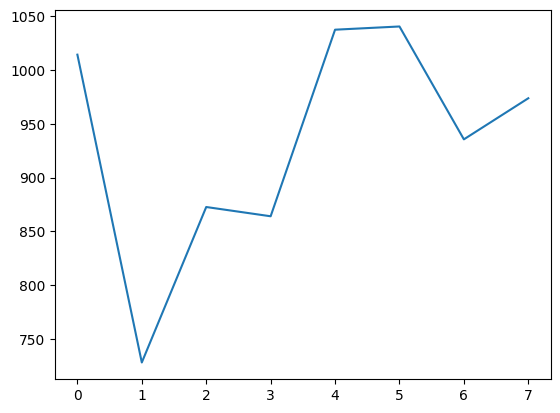

In [32]:
import matplotlib.pyplot as plt  
plt.plot(realtime_loss)

In [5]:
for index, loss in enumerate(realtime_loss):
    print(index, int(loss))

0 252
1 1867
2 3513
3 586
4 7926
5 943
6 588
7 811
8 103
9 2220
10 508
11 528
12 332
13 3293
14 350
15 984
16 404
17 224
18 269
19 2123
20 720
21 360
22 141
23 532
24 5735
25 428
26 261
27 755
28 2991
29 508
30 170
31 48
32 807
33 2315
34 937
35 243
36 10


In [11]:
# threshold = 250 for 3 or more iterations
import pandas as pd
# pd.DataFrame(focus_angles[0][1])
# len(focus_angles)
column = 28
pre = focus_angles[column][0] #pred
act = focus_angles[column][1] #real
# pd.DataFrame({"predicted": pre,"actual":act})
pre, act, realtime_loss[column]

([[122.93067, 128.63292],
  [116.07521, 120.75453],
  [106.51832, 114.691086],
  [104.62581, 117.79407],
  [106.41987, 119.07272]],
 [[153.1046361639737, 157.23949212013775],
  [164.35124725074314, 167.72467564537448],
  [169.55110506001742, 171.57537037233104],
  [173.20577330271954, 174.08909353563996],
  [177.65133105709185, 178.16080649869286]],
 2991.2192656670486)

In [12]:
import torch
import torch.nn as nn
# column = 58
pre = focus_angles[column][0]
act = focus_angles[column][1]

mae_loss = nn.MSELoss()
loss = mae_loss(torch.tensor(pre),torch.tensor(act))
loss.item()

2991.2192656670486

In [17]:
focus_angles[0][1]

[[149.60025066548806, 141.95205928746108],
 [133.08903912145135, 129.68786948933172],
 [134.24730774946974, 131.74074931818853],
 [147.18619993456184, 143.52510528452706],
 [152.57820957623167, 149.81233207017135]]

In [18]:
left_knee_list_real = []
for run in focus_angles:
    for angle in run[1]:
        left_knee_list_real.append(angle[0])

left_knee_list_pred = []
for run in focus_angles:
    for angle in run[0]:
        left_knee_list_pred.append(angle[0])

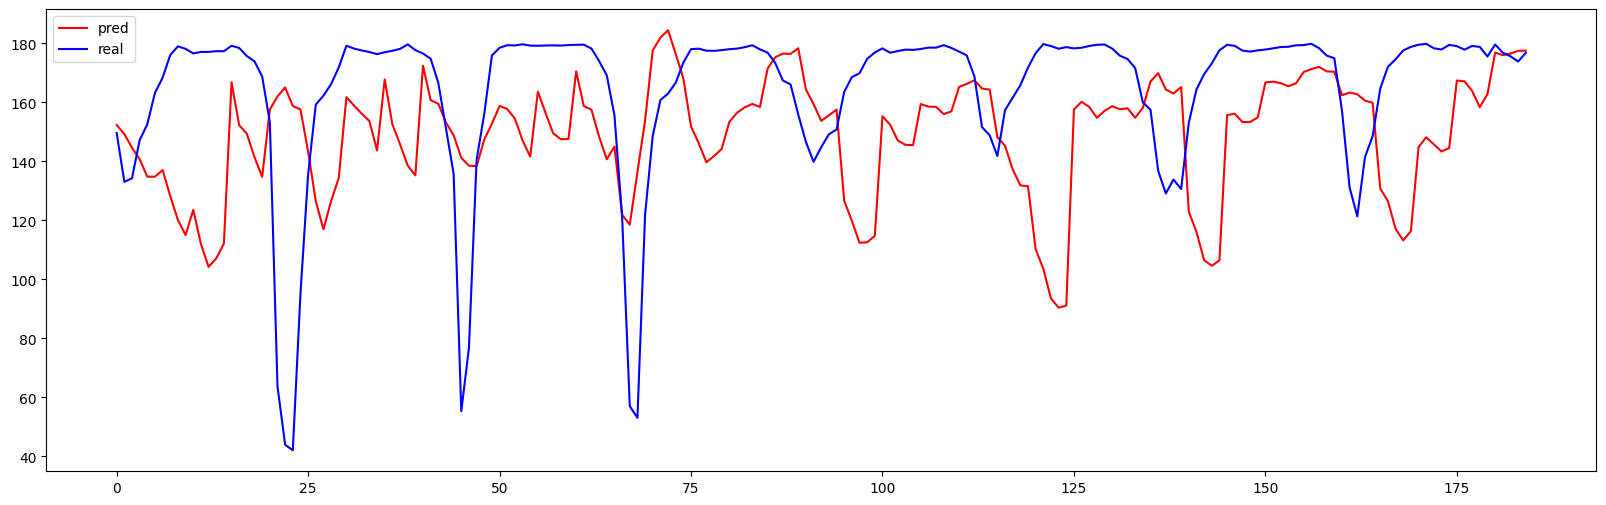

In [19]:
plt.figure(figsize=(20, 6))
plt.plot(left_knee_list_pred, label="pred", color="red")
plt.plot(left_knee_list_real, label="real", color="blue")
plt.legend()
plt.show()

# Make Basic Detection

In [3]:
# Getting video feed
cap = cv2.VideoCapture(0)
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
    while cap.isOpened():
        ret, frame = cap.read()

        # Recolor image to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False 

        # Make detection
        results = pose.process(image)
        
        # Recolor back to BGR
        image.flags.writeable = True 
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

        # Extract landmarks
        try:
            landmarks = results.pose_landmarks.landmark
            print(landmarks)
        except:
            pass

        # Rendering
        mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                  mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=2),
                                  mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2),
                                  )

        cv2.imshow('Raw Webcam Feed', image)
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

# Extract keypoints from a video 

In [23]:
import mediapipe as mp
import cv2
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from collections import deque
import pandas as pd

def calculate_loss(predicted, actual):
    mae_loss = nn.MSELoss()
    loss = mae_loss(torch.tensor(predicted),torch.tensor(actual))
    return loss.item()

def calculate_angle(a, b, c):
    a = np.array(a)  # First
    b = np.array(b)  # Mid
    c = np.array(c)  # End
    
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    
    if angle > 180.0:
        angle = 360 - angle
        
    return angle

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
# Load the LSTM model

# lstm_model = torch.jit.load(r'model_path\model_squats_scripted.pt')#for linux relative path
# lstm_model.to(device) 
# lstm_model.eval()
# Initialize MediaPipe pose
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

# Video Capture
cap = cv2.VideoCapture(r"tanmay pushups\VID-20250404-WA0035.mp4")
# cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
# cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

# Variables for counting and tracking
stage = ""
counter = 0

# Scaling angles
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(np.array([[0] * 7, [180] * 7]))


input_window= 20
output_window = 5
pred_freq = 5

# Store pose sequences
pose_sequences = deque(maxlen=input_window )
real_time_storage = []
frame_count = 0
collecting_real_time = False #this is a flag.false-during prediction, true-calculating real time values. 
predicted_vs_real_storage = [] 
focus_angles=[]
realtime_loss = []
run_buffer=[]
loss_buffer=[]
threshold=300
count = 0
df = pd.DataFrame(columns=["frame_order","right_elbow_right_shoulder_right_hip", "left_elbow_left_shoulder_left_hip", "right_knee_mid_hip_left_knee", "right_hip_right_knee_right_ankle",
                            "left_hip_left_knee_left_ankle", "right_wrist_right_elbow_right_shoulder", "left_wrist_left_elbow_left_shoulder"])
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert frame to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False
        
        # Detect pose
        results = pose.process(image)
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark

            # Draw pose landmarks
            mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                      mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=2),
                                      mp_drawing.DrawingSpec(color=(0,0,255), thickness=2, circle_radius=2))

            # Define angles to calculate
            angles_to_calculate = {
                "right_elbow_right_shoulder_right_hip": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                ],
                "left_elbow_left_shoulder_left_hip": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                ],
                "right_knee_mid_hip_left_knee": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x) / 2,
                     (landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y) / 2],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                ],
                "right_hip_right_knee_right_ankle": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y],
                ],
                "left_hip_left_knee_left_ankle": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].y],
                ],
                "right_wrist_right_elbow_right_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                ],
                "left_wrist_left_elbow_left_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                ],
            }
            # Compute angles
            angles = [calculate_angle(*angles_to_calculate[key]) for key in angles_to_calculate]
            # print(f"Calculated Angles: {angles}")
            # print(angles)
            angles = [int(count)] + angles
            df.loc[count] = angles
            count += 1

        # Show output
        cv2.imshow('Pose Estimation', image)
        if cv2.waitKey(10) & 0xFF == ord('q'):

            break

cap.release()
cv2.destroyAllWindows()

In [24]:
df["frame_order"] = df["frame_order"].astype(int)
df.head()

,frame_order,right_elbow_right_shoulder_right_hip,left_elbow_left_shoulder_left_hip,right_knee_mid_hip_left_knee,right_hip_right_knee_right_ankle,left_hip_left_knee_left_ankle,right_wrist_right_elbow_right_shoulder,left_wrist_left_elbow_left_shoulder
0,0,69.131801,69.488062,50.157357,171.690244,164.791668,167.101954,173.693773
1,1,68.232373,70.325272,51.711561,171.501964,163.395162,166.837190,172.439141
2,2,68.654636,72.166386,52.438742,171.149540,161.246770,165.752170,173.604748
3,3,69.339805,73.726076,52.253583,169.770035,162.323658,166.303944,174.157210
4,4,69.117058,75.723440,52.712997,169.468358,164.742487,166.811494,176.205446


In [25]:
df.to_csv('tantest2.7.csv', index=False)

In [17]:
video_frame_count = 1061  # Number of frames per video

# Generate video_id and frame_order for the original data
video_id = (df['frame_order'] // video_frame_count).astype(int)
df['video_id'] = video_id

# Reorder columns to make video_id the first column
column_order = ['video_id', 'frame_order'] + [col for col in df.columns if col not in ['video_id', 'frame_order']]
df = df[column_order]

# Create 20 duplicates and update video_id sequentially
all_data = []
for i in range(20):
    temp_df = df.copy()
    temp_df['video_id'] = temp_df['video_id'] + i
    all_data.append(temp_df)

df_final = pd.concat(all_data, ignore_index=True)
df_final.to_csv('new_squats.csv', index=False)


In [ ]:
# df.to_csv('hakli_data.csv', index=False)

In [ ]:
# df_repeated = pd.concat([df] * 20, ignore_index=True)
# df_repeated.to_csv('hakli_repeat.csv', index=False)

In [ ]:
# df_repeated.head()

,frame_order,right_elbow_right_shoulder_right_hip,left_elbow_left_shoulder_left_hip,right_knee_mid_hip_left_knee,right_hip_right_knee_right_ankle,left_hip_left_knee_left_ankle,right_wrist_right_elbow_right_shoulder,left_wrist_left_elbow_left_shoulder,video_id
0,0,20.860193,16.034512,28.925374,177.344150,177.770924,176.154408,161.086469,0
1,1,19.777086,15.933075,28.994755,177.597040,178.010313,178.760230,161.040051,0
2,2,18.745600,15.983862,28.944070,177.761838,178.020727,178.572138,161.884094,0
3,3,18.198449,16.337870,28.891036,178.172410,177.808015,177.528918,161.771075,0
4,4,17.828334,16.618230,29.056345,178.276824,177.621667,177.073543,161.813922,0


<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

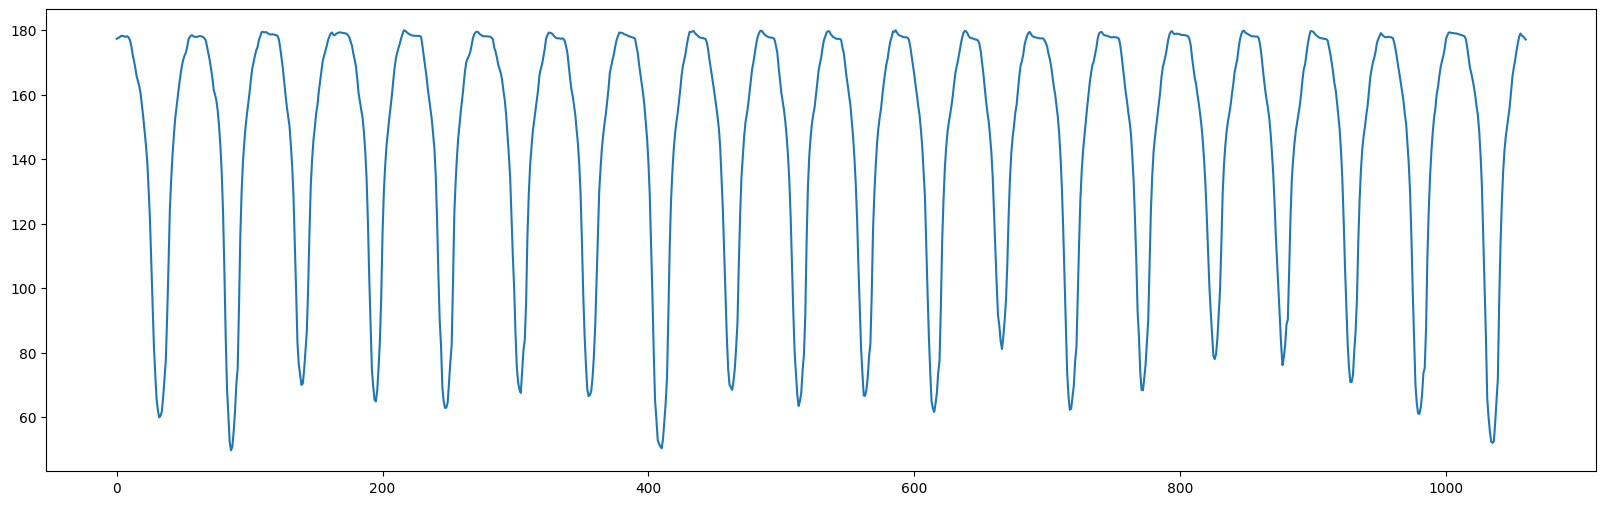

In [7]:
import matplotlib.pyplot as plt  
plt.figure(figsize=(20,6))
plt.plot(df.iloc[:,4])
plt.plot

In [101]:
data = [40.292152280872415,
 41.76803187491497,
 32.0649883255575,
 175.04658384066218,
 178.01065096826343,
 23.947889496301663,
 17.870666463195903]

df = pd.DataFrame(columns=["1","2","3","4","5","6","7"])
df.loc[len(df)] = data
df

,1,2,3,4,5,6,7
0,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666


In [116]:
df.loc[len(df)] = data
df

,1,2,3,4,5,6,7
0,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
1,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
2,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
3,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
4,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
5,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
6,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
7,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
8,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
9,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import sys

mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

pose = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)

cap = cv2.VideoCapture(sys.argv[1])

if cap.isOpened() == False:
    print("Error opening video stream or file")
    raise TypeError

frame_width = int(cap.get(3))
frame_height = int(cap.get(4))

outdir, inputflnm = sys.argv[1][:sys.argv[1].rfind(
    '/')+1], sys.argv[1][sys.argv[1].rfind('/')+1:]
inflnm, inflext = inputflnm.split('.')
out_filename = f'{outdir}{inflnm}_annotated.{inflext}'
out = cv2.VideoWriter(out_filename, cv2.VideoWriter_fourcc(
    'M', 'J', 'P', 'G'), 10, (frame_width, frame_height))

while cap.isOpened():
    ret, image = cap.read()
    if not ret:
        break

    image = cv2.cvtColor(cv2.flip(image, 1), cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = pose.process(image)

    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    mp_drawing.draw_landmarks(
        image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)
    out.write(image)
pose.close()
cap.release()
out.release()


# 2. Determining Joints

<img src="https://i.imgur.com/3j8BPdc.png" style="height:300px" >

In [4]:
landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value]

NameError: name 'landmarks' is not defined

In [ ]:
landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value]

x: 1.01653159
y: 0.86054343
z: -1.10317266
visibility: 0.545346856

# 3. Calculate Angles

In [5]:
def calculate_angle(a,b,c):
    a = np.array(a) # First
    b = np.array(b) # Mid
    c = np.array(c) # End
    
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians*180.0/np.pi)
    
    if angle >180.0:
        angle = 360-angle
        
    return angle 

In [6]:
shoulder = [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y]
elbow = [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x,landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y]
wrist = [landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].x,landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].y]


NameError: name 'landmarks' is not defined

In [7]:
shoulder, elbow, wrist

NameError: name 'shoulder' is not defined

In [ ]:
calculate_angle(shoulder, elbow, wrist)

158.37397025964307

# Holistic

In [ ]:
# mp_drawing = mp.solutions.drawing_utils
# mp_holistic = mp.solutions.holistic

In [ ]:
# import cv2
# import mediapipe as mp

# mp_drawing = mp.solutions.drawing_utils
# mp_drawing_styles = mp.solutions.drawing_styles
# mp_holistic = mp.solutions.holistic
# mp_face_mesh = mp.solutions.face_mesh_connections  # Import face_mesh for FACE_CONNECTIONS

# cap = cv2.VideoCapture(0)

# # Initiate holistic model
# with mp_holistic.Holistic(min_detection_confidence=0.5, 
#                           min_tracking_confidence=0.5,
#                           static_image_mode=False,
#                           smooth_landmarks=True,
#                           model_complexity=2
#                             ) as holistic:
    
#     while cap.isOpened():
#         ret, frame = cap.read()
        
#         # Recolor Feed
#         image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         image.flags.writeable = False        
        
#         # Make Detections
#         results = holistic.process(image)
        
#         # Recolor image back to BGR for rendering
#         image.flags.writeable = True   
#         image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
#         # 1. Draw face landmarks
#         mp_drawing.draw_landmarks(
#             image, results.face_landmarks, mp_face_mesh.FACEMESH_TESSELATION,  # Use FACE_CONNECTIONS from face_mesh module
#             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
#             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
#         )
        
#         # 2. Right hand
#         mp_drawing.draw_landmarks(
#             image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
#         )

#         # 3. Left Hand
#         mp_drawing.draw_landmarks(
#             image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
#         )

#         # 4. Pose Detections
#         mp_drawing.draw_landmarks(
#             image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
#         )
                        
#         cv2.imshow('Holistic Webcam Feed', image)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break

# cap.release()
# cv2.destroyAllWindows()


In [ ]:
# SPINE ANGLE

In [ ]:
# import cv2
# import mediapipe as mp
# import numpy as np

# mp_drawing = mp.solutions.drawing_utils
# mp_pose = mp.solutions.pose

# def calculate_angle(a, b, c):
#     a = np.array(a)  # First point  
#     b = np.array(b)  # Midpoint
#     c = np.array(c)  # End point
    
#     radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
#     angle = np.abs(radians * 180.0 / np.pi)
    
#     if angle > 180.0:
#         angle = 360 - angle
        
#     return angle

# cap = cv2.VideoCapture(0)

# with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
#     while cap.isOpened():
#         ret, frame = cap.read()
        
#         # Recolor image to RGB
#         image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         image.flags.writeable = False

#         # Make detection
#         results = pose.process(image)
        
#         # Recolor back to BGR
#         image.flags.writeable = True
#         image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
#         try:
#             landmarks = results.pose_landmarks.landmark

#             # Get coordinates for back straightness check
#             shoulder = [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,
#                         landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y]
#             hip = [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x,
#                    landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y]
#             knee = [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x,
#                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y]
            
#             # Calculate angle for back straightness
#             spine_angle = calculate_angle(shoulder, hip, knee)
            
#             # Visualize spine angle
#             cv2.putText(image, f'Spine Angle: {int(spine_angle)}', 
#                         (50, 50), 
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2, cv2.LINE_AA)
            
#             # Get foot positions for feet check
#             left_heel_z = landmarks[mp_pose.PoseLandmark.LEFT_HEEL.value].z
#             right_heel_z = landmarks[mp_pose.PoseLandmark.RIGHT_HEEL.value].z
            
#             # Check if feet are lifting off the ground
#             if left_heel_z > 0.25 or right_heel_z > 0.25:  # Adjust threshold as needed
#                 cv2.putText(image, "Feet not planted!", 
#                             (50, 100), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2, cv2.LINE_AA)
#             else:
#                 cv2.putText(image, "Feet planted", 
#                             (50, 100), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2, cv2.LINE_AA)
                       
#         except:
#             pass
        
#         # Render detections
#         mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
#                                   mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
#                                   mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))
        
#         cv2.imshow('Squat Form Detection', image)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break

# cap.release()
# cv2.destroyAllWindows()


# Holistic

In [ ]:
# mp_drawing = mp.solutions.drawing_utils
# mp_holistic = mp.solutions.holistic

In [ ]:
# import cv2
# import mediapipe as mp

# mp_drawing = mp.solutions.drawing_utils
# mp_drawing_styles = mp.solutions.drawing_styles
# mp_holistic = mp.solutions.holistic
# mp_face_mesh = mp.solutions.face_mesh_connections  # Import face_mesh for FACE_CONNECTIONS

# cap = cv2.VideoCapture(0)

# # Initiate holistic model
# with mp_holistic.Holistic(min_detection_confidence=0.5, 
#                           min_tracking_confidence=0.5,
#                           static_image_mode=False,
#                           smooth_landmarks=True,
#                           model_complexity=2
#                             ) as holistic:
    
#     while cap.isOpened():
#         ret, frame = cap.read()
        
#         # Recolor Feed
#         image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         image.flags.writeable = False        
        
#         # Make Detections
#         results = holistic.process(image)
        
#         # Recolor image back to BGR for rendering
#         image.flags.writeable = True   
#         image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
#         # 1. Draw face landmarks
#         mp_drawing.draw_landmarks(
#             image, results.face_landmarks, mp_face_mesh.FACEMESH_TESSELATION,  # Use FACE_CONNECTIONS from face_mesh module
#             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
#             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
#         )
        
#         # 2. Right hand
#         mp_drawing.draw_landmarks(
#             image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
#         )

#         # 3. Left Hand
#         mp_drawing.draw_landmarks(
#             image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
#         )

#         # 4. Pose Detections
#         mp_drawing.draw_landmarks(
#             image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
#         )
                        
#         cv2.imshow('Holistic Webcam Feed', image)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break

# cap.release()
# cv2.destroyAllWindows()


In [ ]:
# SPINE ANGLE

In [ ]:
# import cv2
# import mediapipe as mp
# import numpy as np

# mp_drawing = mp.solutions.drawing_utils
# mp_pose = mp.solutions.pose

# def calculate_angle(a, b, c):
#     a = np.array(a)  # First point  
#     b = np.array(b)  # Midpoint
#     c = np.array(c)  # End point
    
#     radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
#     angle = np.abs(radians * 180.0 / np.pi)
    
#     if angle > 180.0:
#         angle = 360 - angle
        
#     return angle

# cap = cv2.VideoCapture(0)

# with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
#     while cap.isOpened():
#         ret, frame = cap.read()
        
#         # Recolor image to RGB
#         image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         image.flags.writeable = False

#         # Make detection
#         results = pose.process(image)
        
#         # Recolor back to BGR
#         image.flags.writeable = True
#         image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
#         try:
#             landmarks = results.pose_landmarks.landmark

#             # Get coordinates for back straightness check
#             shoulder = [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,
#                         landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y]
#             hip = [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x,
#                    landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y]
#             knee = [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x,
#                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y]
            
#             # Calculate angle for back straightness
#             spine_angle = calculate_angle(shoulder, hip, knee)
            
#             # Visualize spine angle
#             cv2.putText(image, f'Spine Angle: {int(spine_angle)}', 
#                         (50, 50), 
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2, cv2.LINE_AA)
            
#             # Get foot positions for feet check
#             left_heel_z = landmarks[mp_pose.PoseLandmark.LEFT_HEEL.value].z
#             right_heel_z = landmarks[mp_pose.PoseLandmark.RIGHT_HEEL.value].z
            
#             # Check if feet are lifting off the ground
#             if left_heel_z > 0.25 or right_heel_z > 0.25:  # Adjust threshold as needed
#                 cv2.putText(image, "Feet not planted!", 
#                             (50, 100), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2, cv2.LINE_AA)
#             else:
#                 cv2.putText(image, "Feet planted", 
#                             (50, 100), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2, cv2.LINE_AA)
                       
#         except:
#             pass
        
#         # Render detections
#         mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
#                                   mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
#                                   mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))
        
#         cv2.imshow('Squat Form Detection', image)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break

# cap.release()
# cv2.destroyAllWindows()
